In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Fixes Anaconda + PyTorch Windows kernel crash

import json
import re
import torch
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
from rouge_score import rouge_scorer

# 1. Load Master Dataset
print("📥 Loading master_fir_dataset.json...")
with open("master_fir_dataset.json", "r", encoding="utf-8") as f:
    dataset = json.load(f)

print(f"✅ Total FIR records loaded: {len(dataset)}")

# 2. Load BERT Model & Tokenizer from Hugging Face
print("🤖 Loading BERT model (bert-base-uncased)...")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def get_sentence_embedding(sentence):
    """Converts a sentence into a BERT 768-dim vector embedding"""
    inputs = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    # Mean pooling across tokens
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

def bert_summarize(text, num_sentences=2):
    """BERT Extractive Summarizer using sentence cosine similarity"""
    sentences = [s.strip() for s in re.split(r'(?<=[.!?]) +', text) if len(s.strip()) > 5]
    if len(sentences) <= num_sentences:
        return text

    # Compute sentence embeddings
    embeddings = [get_sentence_embedding(s) for s in sentences]
    doc_embedding = np.mean(embeddings, axis=0) # Document centroid

    # Compute cosine similarity score for each sentence
    scores = [cosine_similarity([emb], [doc_embedding])[0][0] for emb in embeddings]

    # Rank and select top N sentences in original order
    top_indices = np.argsort(scores)[-num_sentences:]
    top_indices.sort() # Keep original sentence order
    
    return " ".join([sentences[i] for i in top_indices])

# 3. Test BERT on first 10 samples
results = []
print("\n⚙️ Running BERT Summarization & Calculating ROUGE Scores...\n")

for item in dataset[:10]:
    fir_id = item['fir_id']
    full_text = item['full_text']
    reference_summary = item['summary']
    
    # Generate BERT Summary
    bert_summary = bert_summarize(full_text, num_sentences=2)
    
    # Calculate ROUGE Scores
    scores = scorer.score(reference_summary, bert_summary)
    
    results.append({
        "fir_id": fir_id,
        "crime_category": item['crime_category'],
        "reference_summary": reference_summary,
        "bert_generated_summary": bert_summary,
        "rouge1_f1": round(scores['rouge1'].fmeasure, 4),
        "rouge2_f1": round(scores['rouge2'].fmeasure, 4),
        "rougeL_f1": round(scores['rougeL'].fmeasure, 4)
    })

# 4. Display Results
df_results = pd.DataFrame(results)

print("="*85)
print("📊 BERT SUMMARIZATION & ROUGE EVALUATION RESULTS (FIRST 10 SAMPLES)")
print("="*85)
for idx, r in df_results.iterrows():
    print(f"\n🆔 {r['fir_id']} | Category: {r['crime_category']}")
    print(f"📝 BERT Summary : {r['bert_generated_summary']}")
    print(f"🎯 Reference    : {r['reference_summary']}")
    print(f"📊 ROUGE Scores : R1={r['rouge1_f1']} | R2={r['rouge2_f1']} | RL={r['rougeL_f1']}")

print("\n"+"="*85)
print(f"📈 AVERAGE METRICS across 10 samples:")
print(f"   - Average ROUGE-1 F1: {df_results['rouge1_f1'].mean():.4f}")
print(f"   - Average ROUGE-2 F1: {df_results['rouge2_f1'].mean():.4f}")
print(f"   - Average ROUGE-L F1: {df_results['rougeL_f1'].mean():.4f}")
print("="*85)

📥 Loading master_fir_dataset.json...
✅ Total FIR records loaded: 574
🤖 Loading BERT model (bert-base-uncased)...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

c:\Users\amana\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\amana\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



⚙️ Running BERT Summarization & Calculating ROUGE Scores...

📊 BERT SUMMARIZATION & ROUGE EVALUATION RESULTS (FIRST 10 SAMPLES)

🆔 FIR/2025/0142 | Category: Theft - Chain Snatching
📝 BERT Summary : I, Meena Rajagopal, aged 47, resident of Flat 3B, Green Meadows Apartments, Adyar, Chennai, wish to report that on 12th March 2025 at approximately 7:15 PM, while I was walking back home from Adyar Signal bus stop near the Kasturba Nagar junction, two unidentified men on a black Bajaj Pulsar motorcycle without a number plate approached me from behind. Suresh Kumar, witnessed the incident and can corroborate my statement.
🎯 Reference    : Meena Rajagopal reported that two men on a motorcycle snatched her gold chain worth Rs. 1,20,000 near Kasturba Nagar junction, Chennai, on 12th March 2025, causing minor injuries. A witness has been identified who can support the complaint.
📊 ROUGE Scores : R1=0.4 | R2=0.1667 | RL=0.2364

🆔 FIR/2025/0287 | Category: Cybercrime - Online Financial Fraud
📝 BER

In [2]:
# 1. Define a brand new FIR text (you can change this text to anything!)
new_fir_input = """
On 04/09/2026 at approximately 11:30 AM, complainant Rajesh Sharma was sitting at a coffee shop near MG Road, Bengaluru. 
While he went to the billing counter for two minutes, an unidentified man grabbed his laptop bag from the table. 
The bag contained a MacBook Pro valued at Rs. 1,10,000, his passport, and Rs. 8,000 in cash. 
The suspect ran towards the nearby Metro station. 
CCTV cameras outside the cafe captured a suspect wearing a yellow jacket and black cap. 
The complainant requests urgent police intervention to recover his laptop and documents.
"""

# 2. Generate summary using your BERT model
generated_summary = bert_summarize(new_fir_input, num_sentences=2)

# 3. Print the result
print("="*75)
print("📄 ORIGINAL NEW FIR INPUT:")
print(new_fir_input.strip())

print("\n"+"="*75)
print("🤖 BERT GENERATED SUMMARY:")
print(generated_summary)
print("="*75)

📄 ORIGINAL NEW FIR INPUT:
On 04/09/2026 at approximately 11:30 AM, complainant Rajesh Sharma was sitting at a coffee shop near MG Road, Bengaluru. 
While he went to the billing counter for two minutes, an unidentified man grabbed his laptop bag from the table. 
The bag contained a MacBook Pro valued at Rs. 1,10,000, his passport, and Rs. 8,000 in cash. 
The suspect ran towards the nearby Metro station. 
CCTV cameras outside the cafe captured a suspect wearing a yellow jacket and black cap. 
The complainant requests urgent police intervention to recover his laptop and documents.

🤖 BERT GENERATED SUMMARY:
While he went to the billing counter for two minutes, an unidentified man grabbed his laptop bag from the table. The complainant requests urgent police intervention to recover his laptop and documents.


📥 Loading master_fir_dataset.json...
✅ Successfully loaded 574 FIR records.
🤖 Loading BERT model (bert-base-uncased)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



⚙️ Running BERT Summarization across all 574 samples (progress logged every 50 samples)...

   ⏳ Processed 50/574 FIR records...
   ⏳ Processed 100/574 FIR records...
   ⏳ Processed 150/574 FIR records...
   ⏳ Processed 200/574 FIR records...
   ⏳ Processed 250/574 FIR records...
   ⏳ Processed 300/574 FIR records...
   ⏳ Processed 350/574 FIR records...
   ⏳ Processed 400/574 FIR records...
   ⏳ Processed 450/574 FIR records...
   ⏳ Processed 500/574 FIR records...
   ⏳ Processed 550/574 FIR records...
   ⏳ Processed 574/574 FIR records...

💾 Full evaluation results saved to 'bert_full_evaluation_results.csv'

📊 FINAL FULL DATASET EVALUATION SUMMARY (574 SAMPLES)
   - Mean ROUGE-1 F1 Score: 0.6367 (63.67%)
   - Mean ROUGE-2 F1 Score: 0.3997 (39.97%)
   - Mean ROUGE-L F1 Score: 0.4611 (46.11%)


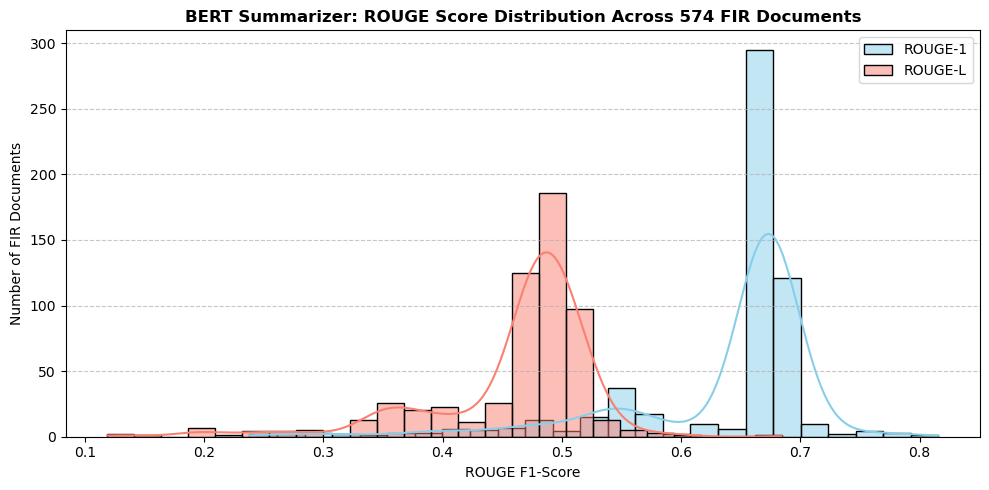

📈 Chart 1 Saved: 'rouge_scores_distribution.png'


C:\Users\amana\AppData\Local\Temp\ipykernel_16220\3842708651.py:110: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_top, x='crime_category', y='rouge1_f1', palette='viridis', ci=None)
C:\Users\amana\AppData\Local\Temp\ipykernel_16220\3842708651.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top, x='crime_category', y='rouge1_f1', palette='viridis', ci=None)


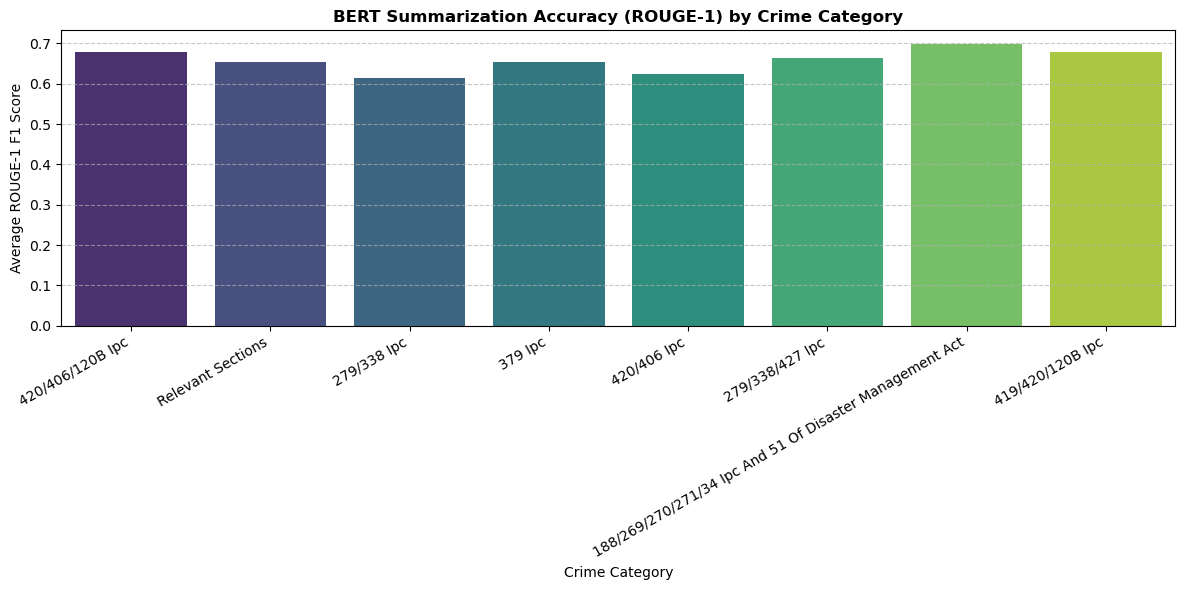

📈 Chart 2 Saved: 'rouge_by_crime_category.png'


In [3]:
import json
import re
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
from rouge_score import rouge_scorer

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 1. Load Master Dataset
print("📥 Loading master_fir_dataset.json...")
with open("master_fir_dataset.json", "r", encoding="utf-8") as f:
    dataset = json.load(f)

total_samples = len(dataset)
print(f"✅ Successfully loaded {total_samples} FIR records.")

# 2. Load BERT Model & Tokenizer
print("🤖 Loading BERT model (bert-base-uncased)...")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def get_sentence_embedding(sentence):
    inputs = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

def bert_summarize(text, num_sentences=2):
    sentences = [s.strip() for s in re.split(r'(?<=[.!?]) +', text) if len(s.strip()) > 5]
    if len(sentences) <= num_sentences:
        return text
    embeddings = [get_sentence_embedding(s) for s in sentences]
    doc_embedding = np.mean(embeddings, axis=0)
    scores = [cosine_similarity([emb], [doc_embedding])[0][0] for emb in embeddings]
    top_indices = np.argsort(scores)[-num_sentences:]
    top_indices.sort()
    return " ".join([sentences[i] for i in top_indices])

# 3. Evaluate across ALL 574 samples
results = []
print(f"\n⚙️ Running BERT Summarization across all {total_samples} samples (progress logged every 50 samples)...\n")

for idx, item in enumerate(dataset):
    fir_id = item.get('fir_id', f"FIR_{idx}")
    category = item.get('crime_category', 'General')
    full_text = item['full_text']
    reference_summary = item['summary']
    
    bert_summary = bert_summarize(full_text, num_sentences=2)
    scores = scorer.score(reference_summary, bert_summary)
    
    results.append({
        "fir_id": fir_id,
        "crime_category": category,
        "full_text": full_text,
        "reference_summary": reference_summary,
        "bert_generated_summary": bert_summary,
        "rouge1_f1": round(scores['rouge1'].fmeasure, 4),
        "rouge2_f1": round(scores['rouge2'].fmeasure, 4),
        "rougeL_f1": round(scores['rougeL'].fmeasure, 4)
    })
    
    if (idx + 1) % 50 == 0 or (idx + 1) == total_samples:
        print(f"   ⏳ Processed {idx + 1}/{total_samples} FIR records...")

# Save detailed results to CSV
df = pd.DataFrame(results)
df.to_csv("bert_full_evaluation_results.csv", index=False)
print(f"\n💾 Full evaluation results saved to 'bert_full_evaluation_results.csv'")

# 4. Overall Statistical Summary
avg_r1 = df['rouge1_f1'].mean()
avg_r2 = df['rouge2_f1'].mean()
avg_rl = df['rougeL_f1'].mean()

print("\n" + "="*80)
print(f"📊 FINAL FULL DATASET EVALUATION SUMMARY ({total_samples} SAMPLES)")
print("="*80)
print(f"   - Mean ROUGE-1 F1 Score: {avg_r1:.4f} ({avg_r1*100:.2f}%)")
print(f"   - Mean ROUGE-2 F1 Score: {avg_r2:.4f} ({avg_r2*100:.2f}%)")
print(f"   - Mean ROUGE-L F1 Score: {avg_rl:.4f} ({avg_rl*100:.2f}%)")
print("="*80)

# 5. Plotting Graph 1: ROUGE Score Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['rouge1_f1'], kde=True, color='skyblue', label='ROUGE-1', bins=25)
sns.histplot(df['rougeL_f1'], kde=True, color='salmon', label='ROUGE-L', bins=25)
plt.title(f'BERT Summarizer: ROUGE Score Distribution Across {total_samples} FIR Documents', fontsize=12, fontweight='bold')
plt.xlabel('ROUGE F1-Score')
plt.ylabel('Number of FIR Documents')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("rouge_scores_distribution.png", dpi=300)
plt.show()
print("📈 Chart 1 Saved: 'rouge_scores_distribution.png'")

# 6. Plotting Graph 2: Top Crime Categories Performance
top_categories = df['crime_category'].value_counts().head(8).index
df_top = df[df['crime_category'].isin(top_categories)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top, x='crime_category', y='rouge1_f1', palette='viridis', ci=None)
plt.title('BERT Summarization Accuracy (ROUGE-1) by Crime Category', fontsize=12, fontweight='bold')
plt.xlabel('Crime Category')
plt.ylabel('Average ROUGE-1 F1 Score')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("rouge_by_crime_category.png", dpi=300)
plt.show()
print("📈 Chart 2 Saved: 'rouge_by_crime_category.png'")